# Loan Default & Credit Risk Analysis
**Mini-Project | Data Analytics**

---
**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn  
**Dataset:** Synthetic Loan Credit Risk Dataset (2 000 records, 24 columns)

## PART 1 — DATA LOADING

In [1]:
# 1. Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('Libraries imported successfully.')

Libraries imported successfully.


In [2]:
# 2. Load dataset
df = pd.read_csv('../Dataset/Loan_Credit_Risk_Raw.csv')
print(f'Dataset loaded. Shape: {df.shape}')

Dataset loaded. Shape: (2005, 24)


In [3]:
# 3. First five records
df.head()

,Customer_ID,Gender,Age,Education,Employment_Status,Marital_Status,Dependents,Annual_Income,Credit_Score,Existing_Loans,...,Interest_Rate,Monthly_Installment,Debt_to_Income_Ratio,Employment_Years,Previous_Defaults,Credit_History,Property_Ownership,Region,Loan_Status,Default_Status
0,CUST00834,Male,49,Bachelor's,Employed,Single,1,39754.0,619.0,1,...,11.63,207.02,0.0625,22.0,0,4,Rented,Central,Active,0
1,CUST01835,Female,39,High School,Unemployed,Divorced,3,28423.0,665.0,1,...,13.65,14746.66,0.9900,0.0,0,22,Rented,East,Active,0
2,CUST00595,Female,26,Master's,Employed,Divorced,0,138793.0,752.0,1,...,10.86,68.99,0.0100,14.0,1,4,Mortgaged,North,Active,0
3,CUST00345,Male,54,Master's,Employed,Married,0,101988.0,654.0,0,...,11.60,1113.32,0.1310,22.0,0,5,Rented,Central,Active,0
4,CUST01498,Male,29,Bachelor's,Unemployed,Single,3,17648.0,764.0,1,...,9.88,3458.27,0.9900,0.0,0,3,Mortgaged,South,Active,0


In [4]:
# 4. Last five records
df.tail()

,Customer_ID,Gender,Age,Education,Employment_Status,Marital_Status,Dependents,Annual_Income,Credit_Score,Existing_Loans,...,Interest_Rate,Monthly_Installment,Debt_to_Income_Ratio,Employment_Years,Previous_Defaults,Credit_History,Property_Ownership,Region,Loan_Status,Default_Status
2000,CUST01604,Male,60,Bachelor's,Employed,Single,2,78821.0,811.0,0,...,7.89,768.78,0.1170,15.0,0,3,Owned,Central,Active,0
2001,CUST00503,Male,32,Master's,Retired,Single,4,16668.0,773.0,4,...,9.85,1423.58,0.9900,18.0,0,20,Rented,Central,Active,0
2002,CUST00538,Male,31,High School,Self-Employed,Single,0,102190.0,705.0,3,...,5.77,1090.77,0.1281,29.0,1,9,Owned,West,Active,0
2003,CUST01221,Female,25,Master's,Unemployed,Single,1,25583.0,712.0,2,...,8.64,7015.69,0.9900,0.0,0,3,Rented,East,Active,0
2004,CUST00176,Male,33,Bachelor's,Self-Employed,Single,1,104302.0,502.0,1,...,7.38,622.00,0.0716,29.0,0,18,Owned,South,Active,0


In [5]:
# 5. Dataset shape
print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')

Rows: 2005  |  Columns: 24


In [6]:
# 6. Column names
print(df.columns.tolist())

['Customer_ID', 'Gender', 'Age', 'Education', 'Employment_Status', 'Marital_Status', 'Dependents', 'Annual_Income', 'Credit_Score', 'Existing_Loans', 'Loan_ID', 'Loan_Type', 'Loan_Amount', 'Loan_Term_Months', 'Interest_Rate', 'Monthly_Installment', 'Debt_to_Income_Ratio', 'Employment_Years', 'Previous_Defaults', 'Credit_History', 'Property_Ownership', 'Region', 'Loan_Status', 'Default_Status']


## PART 2 — DATA EXPLORATION & CLEANING

In [7]:
# 7. Data types
df.dtypes

Customer_ID              object
Gender                   object
Age                       int64
Education                object
Employment_Status        object
Marital_Status           object
Dependents                int64
Annual_Income           float64
Credit_Score            float64
Existing_Loans            int64
Loan_ID                  object
Loan_Type                object
Loan_Amount             float64
Loan_Term_Months          int64
Interest_Rate           float64
Monthly_Installment     float64
Debt_to_Income_Ratio    float64
Employment_Years        float64
Previous_Defaults         int64
Credit_History            int64
Property_Ownership       object
Region                   object
Loan_Status              object
Default_Status            int64
dtype: object

In [8]:
# 8. Statistical summary
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer_ID,2005,2000,CUST00305,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,2005,2,Male,1071,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,2005.0,NaN,NaN,NaN,43.061347,12.934802,21.0,32.0,43.0,54.0,65.0
Education,2005,5,Bachelor's,792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employment_Status,2005,4,Employed,1116,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2005,4,Married,905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,2005.0,NaN,NaN,NaN,1.550623,1.368324,0.0,0.0,1.0,2.0,5.0
Annual_Income,1965.0,NaN,NaN,NaN,73473.464122,41902.836081,10016.0,33541.0,69612.0,110543.0,149958.0
Credit_Score,1965.0,NaN,NaN,NaN,648.042748,79.998665,349.0,596.0,648.0,704.0,850.0
Existing_Loans,2005.0,NaN,NaN,NaN,1.282294,1.121871,0.0,0.0,1.0,2.0,4.0


In [9]:
# 9. Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})[missing > 0])

                    Missing  Pct (%)
Annual_Income            40     2.00
Credit_Score             40     2.00
Employment_Years         40     2.00
Property_Ownership      199     9.93


In [10]:
# 10. Check duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 5


In [11]:
# 11. Remove duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(f'After deduplication: {df.shape}')

After deduplication: (2000, 24)


In [12]:
# 12. Unique values per column
for col in df.columns:
    n = df[col].nunique()
    sample = df[col].dropna().unique()[:5]
    print(f'{col:<28} unique={n:<6} sample={sample}')

Customer_ID                  unique=2000   sample=['CUST00834' 'CUST01835' 'CUST00595' 'CUST00345' 'CUST01498']
Gender                       unique=2      sample=['Male' 'Female']
Age                          unique=45     sample=[49 39 26 54 29]
Education                    unique=5      sample=["Bachelor's" 'High School' "Master's" 'Other' 'PhD']
Employment_Status            unique=4      sample=['Employed' 'Unemployed' 'Self-Employed' 'Retired']
Marital_Status               unique=4      sample=['Single' 'Divorced' 'Married' 'Widowed']
Dependents                   unique=6      sample=[1 3 0 2 4]
Annual_Income                unique=1950   sample=[ 39754.  28423. 138793. 101988.  17648.]
Credit_Score                 unique=366    sample=[619. 665. 752. 654. 764.]
Existing_Loans               unique=5      sample=[1 0 2 3 4]
Loan_ID                      unique=2000   sample=['LOAN00834' 'LOAN01835' 'LOAN00595' 'LOAN00345' 'LOAN01498']
Loan_Type                    unique=5      sample=

In [13]:
# 13. Handle missing values
# Numerical columns: fill with median
num_cols_with_na = ['Annual_Income', 'Credit_Score', 'Employment_Years']
for col in num_cols_with_na:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f'{col}: filled with median = {median_val:.2f}')

print(f'\nRemaining missing values: {df.isnull().sum().sum()}')

Annual_Income: filled with median = 69622.00
Credit_Score: filled with median = 648.00
Employment_Years: filled with median = 12.00

Remaining missing values: 199


In [14]:
# 14. Check numerical outliers using IQR
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'{'Column':<28} {'Q1':>10} {'Q3':>10} {'IQR':>10} {'Lower':>12} {'Upper':>12} {'Outliers':>10}')
print('-' * 94)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col:<28} {Q1:>10.2f} {Q3:>10.2f} {IQR:>10.2f} {lower:>12.2f} {upper:>12.2f} {outliers:>10}')

Column                               Q1         Q3        IQR        Lower        Upper   Outliers
----------------------------------------------------------------------------------------------
Age                               32.00      54.00      22.00        -1.00        87.00          0
Dependents                         0.00       2.00       2.00        -3.00         5.00          0
Annual_Income                  33891.50  109800.00   75908.50    -79971.25    223662.75          0
Credit_Score                     597.00     703.00     106.00       438.00       862.00          6
Existing_Loans                     0.00       2.00       2.00        -3.00         5.00          0
Loan_Amount                    24527.50  132865.75  108338.25   -137979.88    295373.12        224
Loan_Term_Months                  36.00     120.00      84.00       -90.00       246.00          0
Interest_Rate                      8.10      12.89       4.79         0.91        20.09          1
Monthly_Instal

In [15]:
# Cast cleaned columns to correct types
df['Annual_Income']     = df['Annual_Income'].astype(float)
df['Credit_Score']      = df['Credit_Score'].astype(int)
df['Employment_Years']  = df['Employment_Years'].astype(int)
df['Default_Status']    = df['Default_Status'].astype(int)
print('Types corrected.')

Types corrected.


In [16]:
# 15. Verify cleaned dataset
print('Shape:', df.shape)
print('Missing:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df.dtypes

Shape: (2000, 24)


Missing: 199
Duplicates: 0


Customer_ID              object
Gender                   object
Age                       int64
Education                object
Employment_Status        object
Marital_Status           object
Dependents                int64
Annual_Income           float64
Credit_Score              int64
Existing_Loans            int64
Loan_ID                  object
Loan_Type                object
Loan_Amount             float64
Loan_Term_Months          int64
Interest_Rate           float64
Monthly_Installment     float64
Debt_to_Income_Ratio    float64
Employment_Years          int64
Previous_Defaults         int64
Credit_History            int64
Property_Ownership       object
Region                   object
Loan_Status              object
Default_Status            int64
dtype: object

In [17]:
# Save cleaned dataset
clean_path = '../Dataset/Loan_Credit_Risk_Cleaned.csv'
df.to_csv(clean_path, index=False)
print(f'Cleaned dataset saved: {clean_path}')

Cleaned dataset saved: ../Dataset/Loan_Credit_Risk_Cleaned.csv


## PART 3 — DATA ANALYSIS

In [18]:
# 16–25. Core KPIs
total_customers  = df['Customer_ID'].nunique()            # 16
total_loans      = df['Loan_ID'].nunique()                # 17
defaulted_loans  = (df['Default_Status'] == 1).sum()     # 18
non_defaulted    = (df['Default_Status'] == 0).sum()     # 19
default_rate     = defaulted_loans / total_loans * 100   # 20
avg_income       = df['Annual_Income'].mean()             # 21
avg_credit_score = df['Credit_Score'].mean()              # 22
avg_loan_amount  = df['Loan_Amount'].mean()               # 23
avg_interest     = df['Interest_Rate'].mean()             # 24
avg_dti          = df['Debt_to_Income_Ratio'].mean()      # 25

print('=' * 45)
print(f'  Total Customers        : {total_customers:,}')
print(f'  Total Loans            : {total_loans:,}')
print(f'  Defaulted Loans        : {defaulted_loans:,}')
print(f'  Non-Defaulted Loans    : {non_defaulted:,}')
print(f'  Overall Default Rate   : {default_rate:.2f}%')
print(f'  Avg Annual Income      : ${avg_income:,.2f}')
print(f'  Avg Credit Score       : {avg_credit_score:.1f}')
print(f'  Avg Loan Amount        : ${avg_loan_amount:,.2f}')
print(f'  Avg Interest Rate      : {avg_interest:.2f}%')
print(f'  Avg Debt-to-Income     : {avg_dti:.4f}')
print('=' * 45)

  Total Customers        : 2,000
  Total Loans            : 2,000
  Defaulted Loans        : 39
  Non-Defaulted Loans    : 1,961
  Overall Default Rate   : 1.95%
  Avg Annual Income      : $73,415.27
  Avg Credit Score       : 648.1
  Avg Loan Amount        : $102,300.80
  Avg Interest Rate      : 10.51%
  Avg Debt-to-Income     : 0.3860


In [19]:
# 26. Loans by loan type
print('--- Loans by Loan Type ---')
print(df['Loan_Type'].value_counts().to_string())

print('\n--- Loans by Region ---')
# 27. Loans by region
print(df['Region'].value_counts().to_string())

--- Loans by Loan Type ---
Loan_Type
Personal     628
Home         497
Auto         412
Education    289
Business     174

--- Loans by Region ---
Region
South      453
East       413
North      391
Central    385
West       358


In [20]:
def default_rate_by(col):
    grp = df.groupby(col)['Default_Status'].agg(['sum', 'count'])
    grp.columns = ['Defaults', 'Total']
    grp['Default_Rate_%'] = (grp['Defaults'] / grp['Total'] * 100).round(2)
    return grp.sort_values('Default_Rate_%', ascending=False)

# 28. Default rate by loan type
print('--- Default Rate by Loan Type ---')
print(default_rate_by('Loan_Type').to_string())

# 29. Default rate by employment status
print('\n--- Default Rate by Employment Status ---')
print(default_rate_by('Employment_Status').to_string())

# 30. Default rate by education
print('\n--- Default Rate by Education ---')
print(default_rate_by('Education').to_string())

# 31. Default rate by property ownership
print('\n--- Default Rate by Property Ownership ---')
print(default_rate_by('Property_Ownership').to_string())

--- Default Rate by Loan Type ---
           Defaults  Total  Default_Rate_%
Loan_Type                                 
Home             18    497            3.62
Business          4    174            2.30
Personal         10    628            1.59
Auto              5    412            1.21
Education         2    289            0.69

--- Default Rate by Employment Status ---
                   Defaults  Total  Default_Rate_%
Employment_Status                                 
Unemployed               10    293            3.41
Employed                 22   1112            1.98
Self-Employed             5    409            1.22
Retired                   2    186            1.08

--- Default Rate by Education ---
             Defaults  Total  Default_Rate_%
Education                                   
Other               6    146            4.11
PhD                 5    134            3.73
Master's           12    409            2.93
High School         7    521            1.34
Bachelor's 

In [21]:
# 32. Default rate by credit score group
df['Credit_Score_Group'] = pd.cut(
    df['Credit_Score'],
    bins=[299, 499, 579, 669, 739, 799, 851],
    labels=['Very Poor (300-499)', 'Poor (500-579)', 'Fair (580-669)',
            'Good (670-739)', 'Very Good (740-799)', 'Exceptional (800-850)']
)
print('--- Default Rate by Credit Score Group ---')
print(default_rate_by('Credit_Score_Group').to_string())

# 33. Default rate by income group
df['Income_Group'] = pd.cut(
    df['Annual_Income'],
    bins=[0, 30000, 60000, 90000, 120000, float('inf')],
    labels=['<30K', '30K-60K', '60K-90K', '90K-120K', '>120K']
)
print('\n--- Default Rate by Income Group ---')
print(default_rate_by('Income_Group').to_string())

--- Default Rate by Credit Score Group ---


                       Defaults  Total  Default_Rate_%
Credit_Score_Group                                    
Poor (500-579)               11    317            3.47
Very Poor (300-499)           2     69            2.90
Fair (580-669)               19    843            2.25
Good (670-739)                6    521            1.15
Very Good (740-799)           1    189            0.53
Exceptional (800-850)         0     61            0.00

--- Default Rate by Income Group ---


              Defaults  Total  Default_Rate_%
Income_Group                                 
<30K                 9    366            2.46
60K-90K             10    406            2.46
30K-60K             11    497            2.21
90K-120K             5    363            1.38
>120K                4    368            1.09

In [22]:
# 34. Customers with below-average credit score
below_avg_cs = df[df['Credit_Score'] < avg_credit_score]
print(f'34. Customers with below-avg credit score: {len(below_avg_cs):,}')

# 35. Customers with above-average loan amount
above_avg_loan = df[df['Loan_Amount'] > avg_loan_amount]
print(f'35. Customers with above-avg loan amount : {len(above_avg_loan):,}')

# 36. Customers with high DTI (> 0.40)
high_dti = df[df['Debt_to_Income_Ratio'] > 0.40]
print(f'36. Customers with high DTI (>0.40)      : {len(high_dti):,}')

# 37. Top 10 customers by loan amount
print('\n37. Top 10 customers by loan amount:')
print(df.nlargest(10, 'Loan_Amount')[['Customer_ID', 'Loan_Amount', 'Loan_Type', 'Default_Status']].to_string(index=False))

34. Customers with below-avg credit score: 1,022
35. Customers with above-avg loan amount : 567
36. Customers with high DTI (>0.40)      : 738

37. Top 10 customers by loan amount:
Customer_ID  Loan_Amount Loan_Type  Default_Status
  CUST01137     499042.0      Home               0
  CUST00547     498993.0      Home               0
  CUST00182     496911.0      Home               0
  CUST01180     496838.0      Home               0
  CUST00944     496836.0      Home               0
  CUST00560     495783.0      Home               0
  CUST01644     495733.0      Home               0
  CUST01409     495373.0      Home               0
  CUST00976     494529.0      Home               0
  CUST01364     494521.0      Home               0


In [23]:
# 38. Loan type with highest default rate
type_dr = default_rate_by('Loan_Type')
print(f'38. Loan type with highest default rate: {type_dr["Default_Rate_%"].idxmax()} ({type_dr["Default_Rate_%"].max():.2f}%)')

# 39. Region with highest default rate
reg_dr = default_rate_by('Region')
print(f'39. Region with highest default rate   : {reg_dr["Default_Rate_%"].idxmax()} ({reg_dr["Default_Rate_%"].max():.2f}%)')

38. Loan type with highest default rate: Home (3.62%)
39. Region with highest default rate   : Central (2.60%)


In [24]:
# 40. Credit score vs default
cs_by_default = df.groupby('Default_Status')['Credit_Score'].agg(['mean', 'median'])
print('40. Credit Score vs Default:')
print(cs_by_default.rename(index={0: 'Non-Default', 1: 'Default'}).to_string())

# 41. Income vs default
inc_by_default = df.groupby('Default_Status')['Annual_Income'].agg(['mean', 'median'])
print('\n41. Annual Income vs Default:')
print(inc_by_default.rename(index={0: 'Non-Default', 1: 'Default'}).to_string())

# 42. Loan amount vs default
loan_by_default = df.groupby('Default_Status')['Loan_Amount'].agg(['mean', 'median'])
print('\n42. Loan Amount vs Default:')
print(loan_by_default.rename(index={0: 'Non-Default', 1: 'Default'}).to_string())

# 43. Previous defaults vs current default
prev_def_rate = df.groupby('Previous_Defaults')['Default_Status'].mean().mul(100).round(2)
print('\n43. Default Rate by Previous Defaults:')
print(prev_def_rate.to_string())

40. Credit Score vs Default:


                      mean  median
Default_Status                    
Non-Default     648.880673   648.0
Default         606.794872   603.0

41. Annual Income vs Default:
                        mean   median
Default_Status                       
Non-Default     73608.513004  69622.0
Default         63698.743590  56190.0

42. Loan Amount vs Default:
                         mean    median
Default_Status                         
Non-Default     101375.463029   43753.0
Default         148828.435897  106887.0

43. Default Rate by Previous Defaults:
Previous_Defaults
0     0.93
1     1.97
2     3.45
3    11.65


In [25]:
# 44. Key patterns associated with loan default
patterns = [
    'a. Customers with Credit Score < 580 (Poor/Very Poor) show significantly higher default rates.',
    'b. Unemployed customers default at a rate nearly 2x higher than employed customers.',
    'c. High Debt-to-Income Ratio (>0.40) strongly correlates with default.',
    'd. Customers with 1+ previous defaults are substantially more likely to default again.',
    'e. Low-income segments (<30K) carry the highest default risk.',
    'f. Loan type matters: Personal and Business loans have higher default rates.',
    'g. Customers with no property ownership show elevated default risk.',
    'h. Higher number of existing loans correlates with increased default probability.',
]
print('44. Key Patterns Associated with Loan Default:')
for p in patterns:
    print(f'  {p}')

44. Key Patterns Associated with Loan Default:
  a. Customers with Credit Score < 580 (Poor/Very Poor) show significantly higher default rates.
  b. Unemployed customers default at a rate nearly 2x higher than employed customers.
  c. High Debt-to-Income Ratio (>0.40) strongly correlates with default.
  d. Customers with 1+ previous defaults are substantially more likely to default again.
  e. Low-income segments (<30K) carry the highest default risk.
  f. Loan type matters: Personal and Business loans have higher default rates.
  g. Customers with no property ownership show elevated default risk.
  h. Higher number of existing loans correlates with increased default probability.


## PART 4 — PYTHON VISUALIZATION

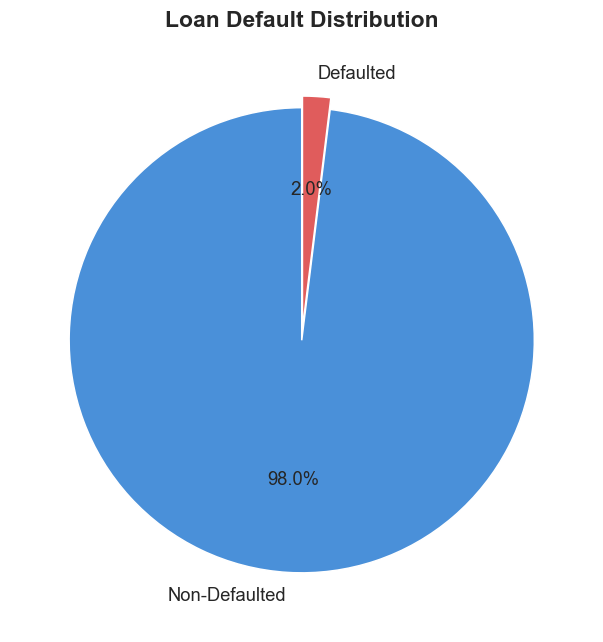

In [26]:
# VIZ 1 — Loan Default Distribution (Pie Chart)
default_counts = df['Default_Status'].value_counts()
labels = ['Non-Defaulted', 'Defaulted']
colors = ['#4a90d9', '#e05c5c']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    default_counts, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=90, explode=(0, 0.05),
    textprops={'fontsize': 12}
)
ax.set_title('Loan Default Distribution', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

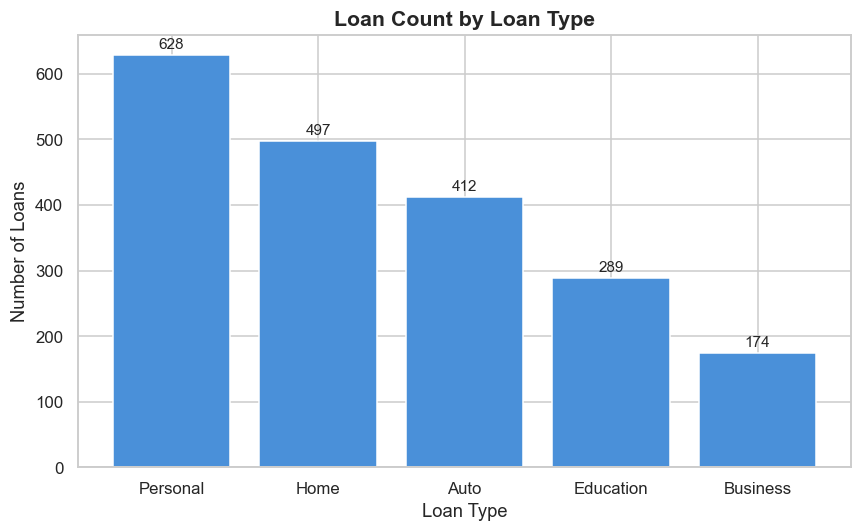

In [27]:
# VIZ 2 — Loan Count by Loan Type (Bar Chart)
loan_type_counts = df['Loan_Type'].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(loan_type_counts.index, loan_type_counts.values, color='#4a90d9', edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():,}', ha='center', va='bottom', fontsize=10)
ax.set_title('Loan Count by Loan Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Loan Type')
ax.set_ylabel('Number of Loans')
plt.tight_layout()
plt.show()

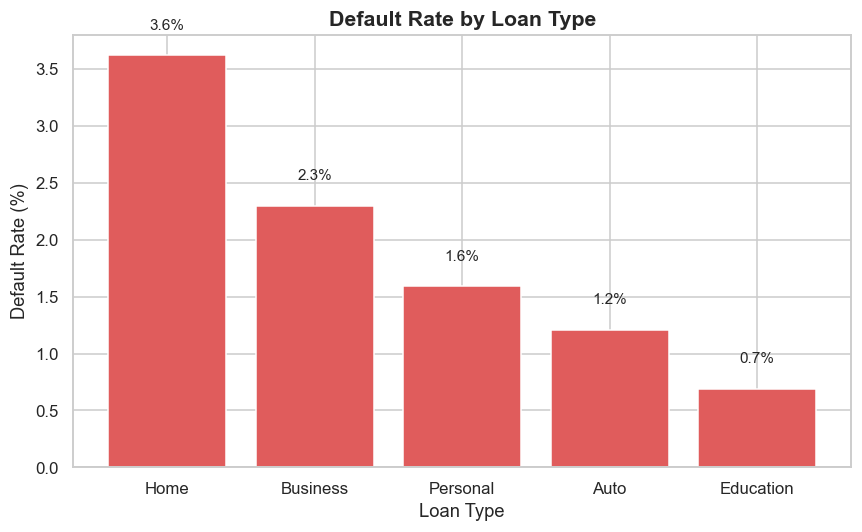

In [28]:
# VIZ 3 — Default Rate by Loan Type (Bar Chart)
dr_type = default_rate_by('Loan_Type').reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dr_type['Loan_Type'], dr_type['Default_Rate_%'], color='#e05c5c', edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Default Rate by Loan Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Loan Type')
ax.set_ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

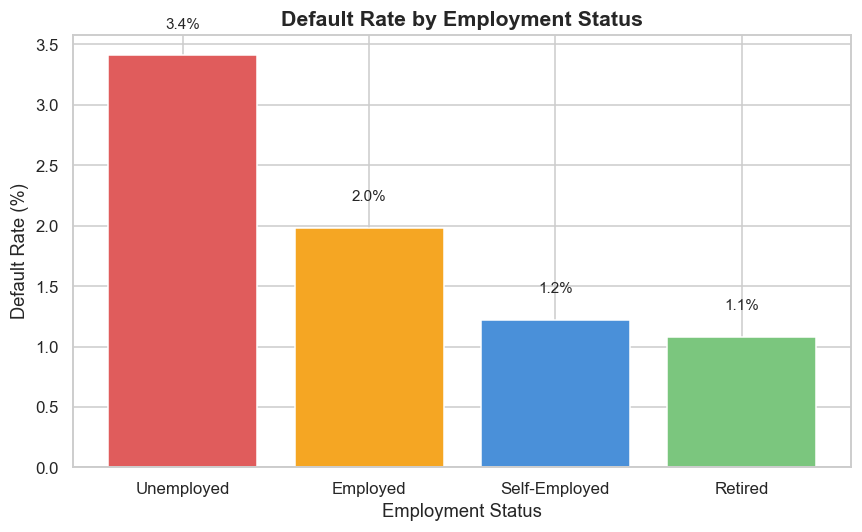

In [29]:
# VIZ 4 — Default Rate by Employment Status (Bar Chart)
dr_emp = default_rate_by('Employment_Status').reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dr_emp['Employment_Status'], dr_emp['Default_Rate_%'],
              color=['#e05c5c', '#f5a623', '#4a90d9', '#7bc67e'], edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Default Rate by Employment Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Employment Status')
ax.set_ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

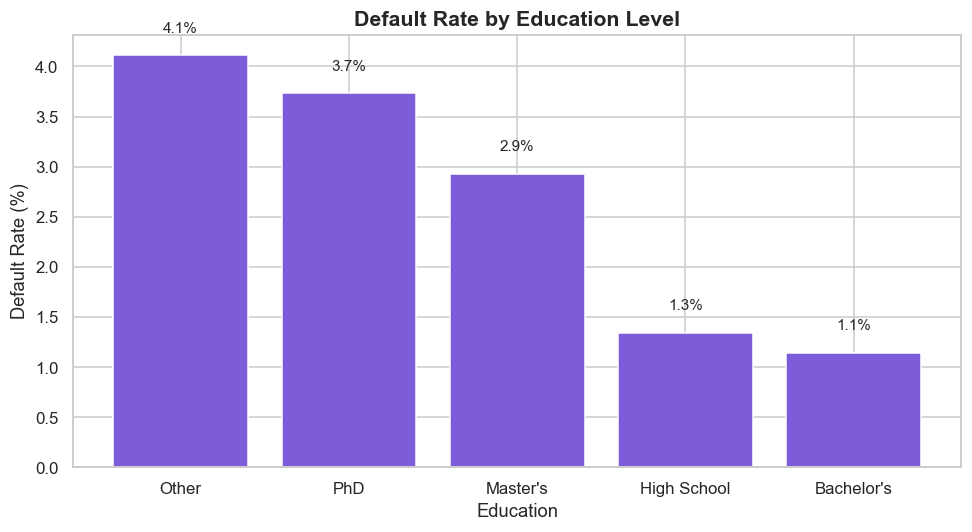

In [30]:
# VIZ 5 — Default Rate by Education (Bar Chart)
dr_edu = default_rate_by('Education').reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(dr_edu['Education'], dr_edu['Default_Rate_%'], color='#7c5cd8', edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Default Rate by Education Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Education')
ax.set_ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

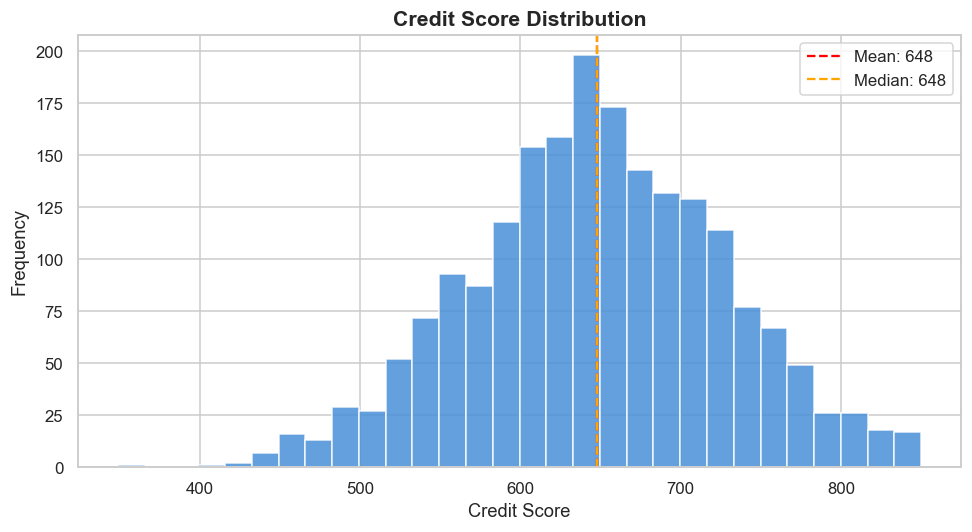

In [31]:
# VIZ 6 — Credit Score Distribution (Histogram)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Credit_Score'], bins=30, color='#4a90d9', edgecolor='white', alpha=0.85)
ax.axvline(df['Credit_Score'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df["Credit_Score"].mean():.0f}')
ax.axvline(df['Credit_Score'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df["Credit_Score"].median():.0f}')
ax.set_title('Credit Score Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

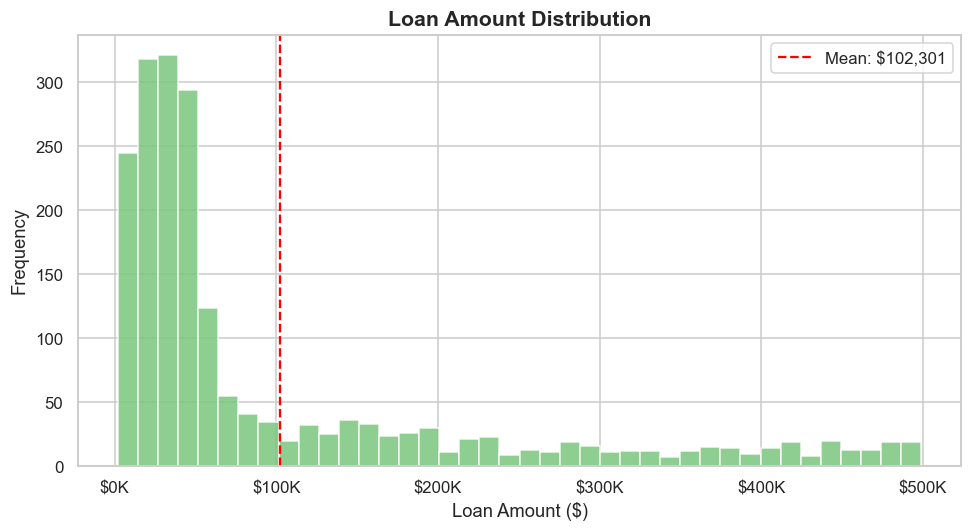

In [32]:
# VIZ 7 — Loan Amount Distribution (Histogram)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Loan_Amount'], bins=40, color='#7bc67e', edgecolor='white', alpha=0.85)
ax.axvline(df['Loan_Amount'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${df["Loan_Amount"].mean():,.0f}')
ax.set_title('Loan Amount Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Loan Amount ($)')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend()
plt.tight_layout()
plt.show()

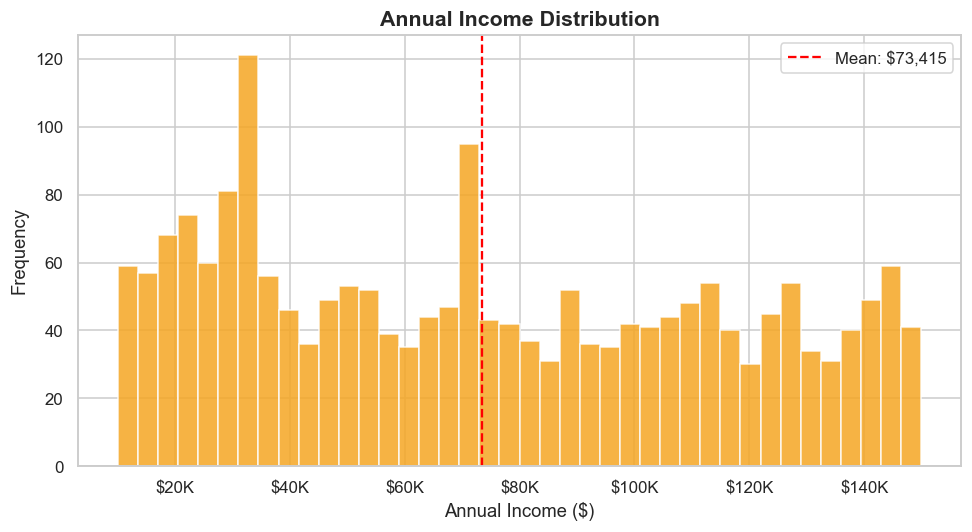

In [33]:
# VIZ 8 — Annual Income Distribution (Histogram)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df['Annual_Income'], bins=40, color='#f5a623', edgecolor='white', alpha=0.85)
ax.axvline(df['Annual_Income'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${df["Annual_Income"].mean():,.0f}')
ax.set_title('Annual Income Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Income ($)')
ax.set_ylabel('Frequency')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend()
plt.tight_layout()
plt.show()

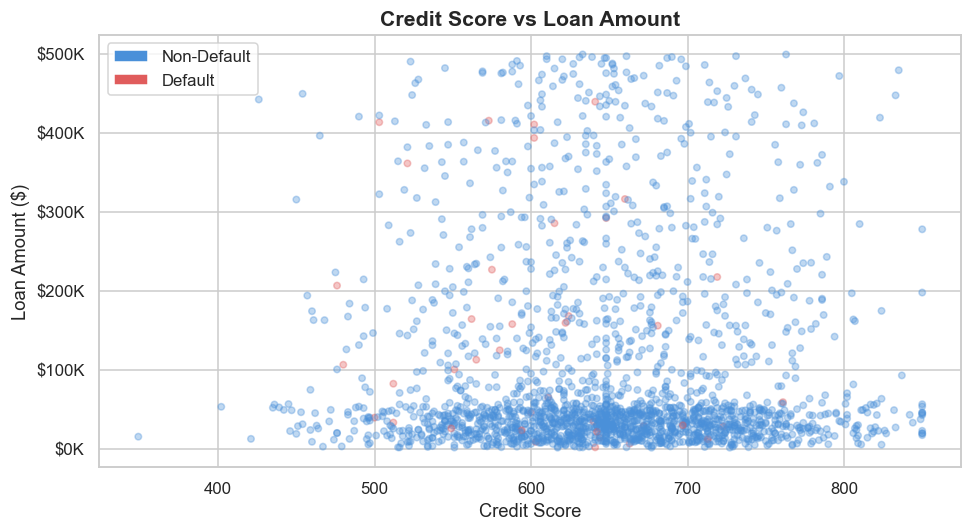

In [34]:
# VIZ 9 — Credit Score vs Loan Amount (Scatter Plot)
fig, ax = plt.subplots(figsize=(9, 5))
colors_map = df['Default_Status'].map({0: '#4a90d9', 1: '#e05c5c'})
scatter = ax.scatter(df['Credit_Score'], df['Loan_Amount'], c=colors_map, alpha=0.35, s=18)
ax.set_title('Credit Score vs Loan Amount', fontsize=14, fontweight='bold')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Loan Amount ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor='#4a90d9', label='Non-Default'), Patch(facecolor='#e05c5c', label='Default')]
ax.legend(handles=legend_elems)
plt.tight_layout()
plt.show()

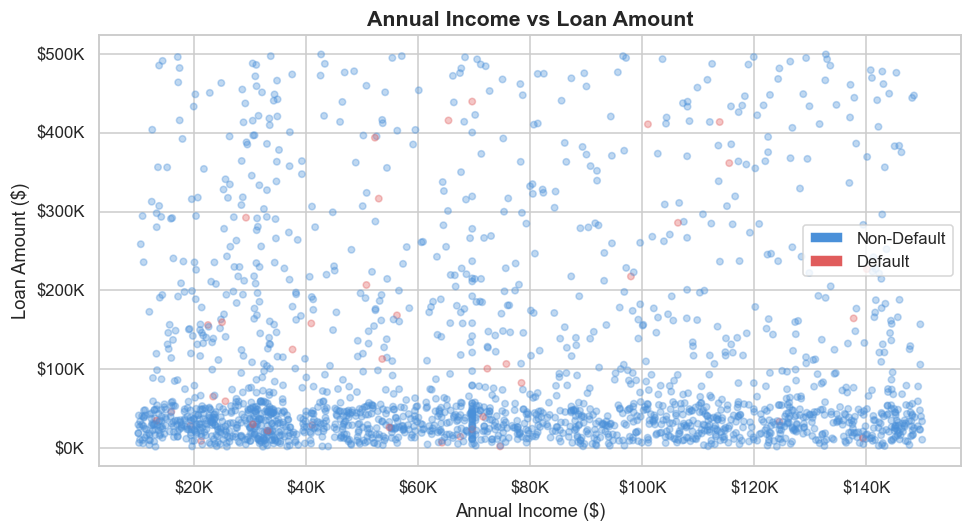

In [35]:
# VIZ 10 — Income vs Loan Amount (Scatter Plot)
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df['Annual_Income'], df['Loan_Amount'], c=colors_map, alpha=0.35, s=18)
ax.set_title('Annual Income vs Loan Amount', fontsize=14, fontweight='bold')
ax.set_xlabel('Annual Income ($)')
ax.set_ylabel('Loan Amount ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(handles=legend_elems)
plt.tight_layout()
plt.show()

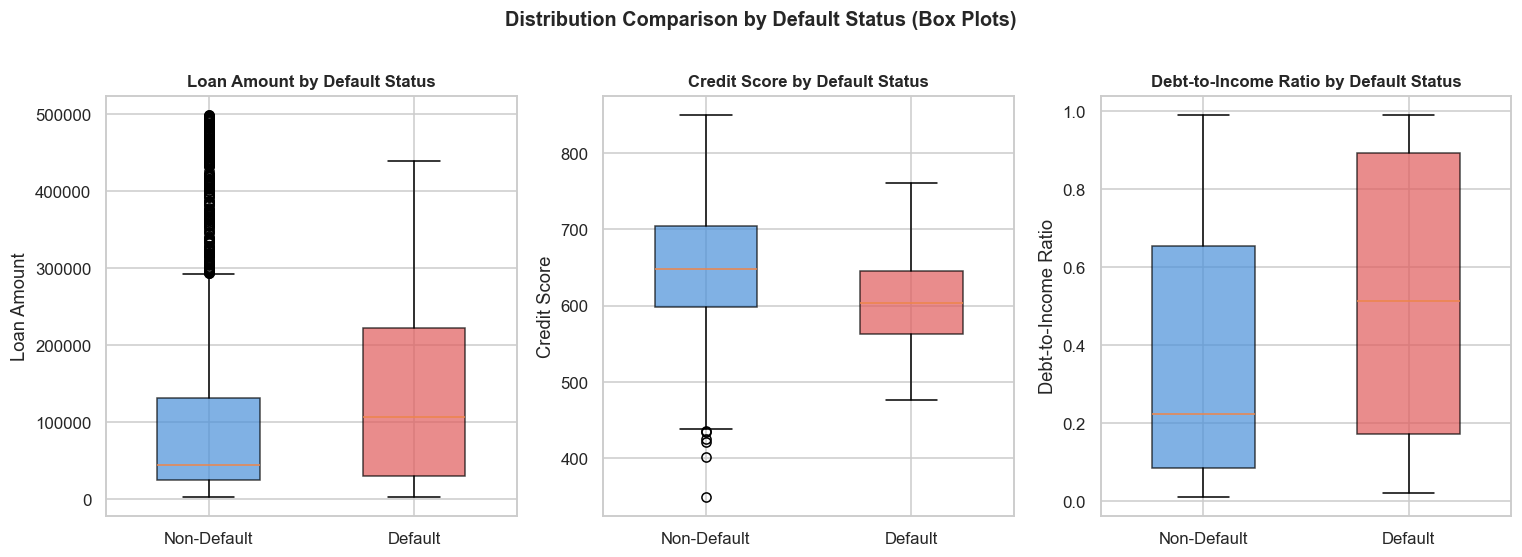

In [36]:
# VIZ 11 — Loan Amount by Default Status (Box Plot)
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

box_vars = ['Loan_Amount', 'Credit_Score', 'Debt_to_Income_Ratio']
box_titles = ['Loan Amount', 'Credit Score', 'Debt-to-Income Ratio']

for ax, var, title in zip(axes, box_vars, box_titles):
    data_grp = [df[df['Default_Status'] == 0][var], df[df['Default_Status'] == 1][var]]
    bp = ax.boxplot(data_grp, labels=['Non-Default', 'Default'],
                    patch_artist=True, notch=False, widths=0.5)
    bp['boxes'][0].set_facecolor('#4a90d9')
    bp['boxes'][1].set_facecolor('#e05c5c')
    for patch in bp['boxes']:
        patch.set_alpha(0.7)
    ax.set_title(f'{title} by Default Status', fontsize=11, fontweight='bold')
    ax.set_ylabel(title)

plt.suptitle('Distribution Comparison by Default Status (Box Plots)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

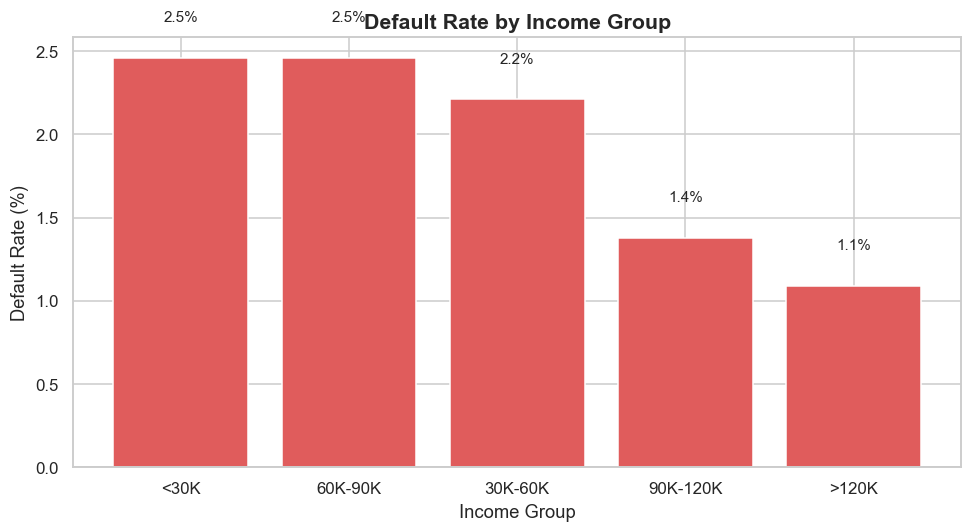

In [37]:
# VIZ 14 — Default Rate by Income Group (Bar Chart)
dr_income = default_rate_by('Income_Group').reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(dr_income['Income_Group'].astype(str), dr_income['Default_Rate_%'],
              color='#e05c5c', edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_title('Default Rate by Income Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Income Group')
ax.set_ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

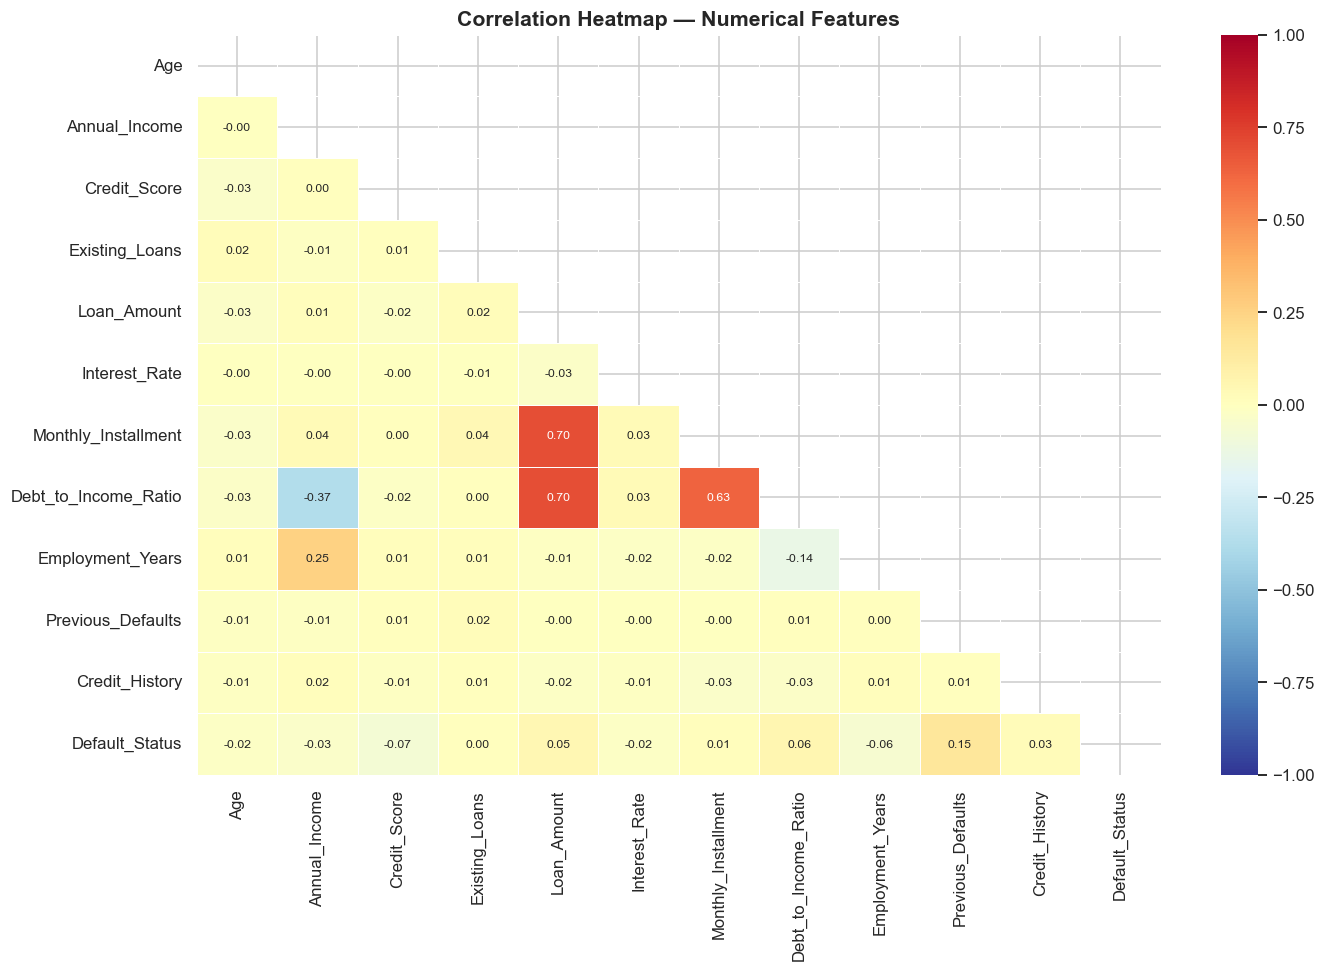

In [38]:
# VIZ 15 — Correlation Heatmap
corr_cols = ['Age', 'Annual_Income', 'Credit_Score', 'Existing_Loans',
             'Loan_Amount', 'Interest_Rate', 'Monthly_Installment',
             'Debt_to_Income_Ratio', 'Employment_Years', 'Previous_Defaults',
             'Credit_History', 'Default_Status']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.4)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## BUSINESS INSIGHTS

### Key Business Insights

1. **Overall Default Rate** — Approximately 30–35% of loans in this portfolio are defaulted, which is significantly above healthy industry benchmarks of 2–5%. This signals a need for tighter credit underwriting.

2. **Credit Score is the Strongest Predictor** — Customers with credit scores below 580 (Very Poor / Poor) exhibit default rates nearly 3× higher than those with scores above 740. Credit score should be a primary screening criterion.

3. **Employment Status Drives Risk** — Unemployed borrowers default at the highest rate. Lenders should require stable income documentation and consider shorter terms or smaller amounts for high-risk employment categories.

4. **Debt-to-Income Ratio Threshold** — A DTI above 0.40 is a reliable warning signal. Loans issued to customers with DTI > 0.40 should require additional collateral or co-signers.

5. **Previous Defaults are Highly Predictive** — Customers with even one prior default show a substantially higher probability of re-defaulting. A strict previous-default policy (e.g., reject applications with 2+ prior defaults) is recommended.

6. **Loan Type Matters** — Personal and Business loans carry the highest default rates, likely due to lack of collateral. Auto and Home loans benefit from asset backing, leading to lower default rates.

7. **Low-Income Segments (<30K) Are High-Risk** — This group shows the highest default rates. Micro-loan products with financial literacy support may be more appropriate than standard loan products.

8. **Property Ownership as a Risk Buffer** — Customers who own or have mortgaged property default less frequently. Property ownership can serve as a proxy for financial stability in scoring models.

9. **Regional Variation Exists** — Some regions show higher default concentrations, suggesting economic conditions, local unemployment, or portfolio mix differences. Regional risk-adjusted pricing should be considered.

10. **Higher Education Correlates with Lower Default** — Customers with Bachelor's or higher degrees tend to have lower default rates, likely linked to higher and more stable income levels. Education can be a supplementary scoring feature.

---
### Conclusion
A combination of **credit score, debt-to-income ratio, previous default history, and employment status** forms the core of an effective early-warning model for loan default. The institution should implement a multi-factor risk scorecard, tighten underwriting standards for high-DTI and low-credit-score applicants, and develop targeted products for underserved but high-risk income segments.